<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 4</center></b><h2>
<h3><b><center>Orbitas alrededor de un agujero negro</center></b><h3>
<h5><center><b>Asignada</b>: 4 de agosto de 2025</center><h5>
<h5><center><b>Entrega</b>: 24 de agosto de 2025</center><h5>
<h7><center><i>Última actualización del profesor</b>: Lunes 4 de julio de 2025, 10:00 pm</i></center><h7>
</p>

<hr/>
<b>Nombre</b>: María Isabel Olarte García
<br/>
<b>Cédula</b>: 1034986320
<br/>
<b>Última actualización</b>: 26 de agosto de 2025, 11:50 pm
<hr/>

## Enunciado

Vamos a simular el movimiento de una partícula alrededor de un agujero negro usando para ello el Lagrangiano específico del problema del problema relativo de los dos cuerpos en coordenadas esféricas:

$$
L_{2 B}=\frac{1}{2}\left(\dot{r}^2+r^2 \cos ^2 \phi \dot{\theta}^2+r^2 \dot{\phi}^2\right)-V(r)
$$
usando como potencial efectivo el potencial predicho por la teoría general de la relatividad:

$$
V(r) = -\frac{G M}{r}-\frac{h^2 R_S}{2 r^3}
$$
donde $h^2$ es el momentum angular específico y $R_S = 2GM/c^2$ es el radio de Schwarzschild del agujero negro.

Para hacerlo sugiero:

1. Usando el lagrangiano y las ecuaciones de Euler Lagrange, deduzca las ecuaciones de movimiento del sistema y calcule, usando el teorema de Noether las cuadraturas (constantes de movimiento) del problema.

2. Escogiendo unidades apropiadas, que en el caso de agujeros negros lo conveniente es usar un sistema de unidades tales que $U_M = M$, $G=1$ y $c=1$ y fijando condiciones iniciales que garanticen que $r\gg R_S$, resuelva las ecuaciones de movimiento para distintas condiciones iniciales y observe las órbitas resultantes. Cómo se compara el resultado con el que se obtendría usando la teoría newtoniana (el potencial newtoniano).

3. Repita el procedimiento anterior pero usando ahora el formalismo Hamiltoniano. Es decir, escriba el Hamiltoniano del sistema, deduzca a partir de él las ecuaciones de movimiento, las constantes del problema y resuelva numéricamente las ecuaciones resultantes para predecir el movimiento del sistema. Verifique que la solución obtenida coincide con la del formalismo Lagrangiano.

4. Vamos a estudiar numérica y teóricamente el que fue el primer efecto estudiado por Albert Einstein usando la teoría general de la relatividad: la precesión del perihelio. Cree una configuración en la que se haga evidente el efecto de precesión del perihelio. Mida la velocidad de avance del perihelio numericamente y comparela con las predicciones de la teoría general de la relatividad (ver libro del profesor).

5. De acuerdo con el formalismo Hamiltoniano, la velocidad de cambio de una función para un sistema en el que el Hamiltoniano no depende explícitamente del tiempo, esta dada por:

  $$
  \frac{df}{dt} = \{H,f\}
  $$

  Use este resultado para calcular la variación en el tiempo del vector de excentricidad $\vec e = (\vec v\times\vec h)/\mu - \vec{r}/r$. En coordenadas cilíndricas, la variación de $\vec e$ se puede escribir como:
  
  $$
  \frac{d \vec{e}}{d t}=\left(\frac{d e_r}{d t}-e_\theta \dot{\theta}\right) \hat{u}_r+\left(\frac{d e_\theta}{d t}+u_r \dot{\theta}\right) \hat{u}_\theta
  $$
  ¿Qué puede concluir de su análisis y cómo se relaciona ese resultado con la precesión del perihelio?.

**NOTA**: Algunas correcciones al enunciado pueden ser publicadas con posterioridad a la formulación de la tarea. Es importante que este pendiente de la última versión de este documento antes de enviar la solución.

### Condiciones

Lea con atención está lista de condiciones que deben cumplirse al entregar la tarea para evitar sanciones en la calificación asignada:

  - La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
  - Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
  - En caso de usar IAs para alguna parte de la solución, debe indicar qué herramienta usa en cada caso presentrar el/los *prompts* usados (agreguelos como comentarios siempre).
  - La solución debe entregarse exclusivamente como un *notebook* de Colab. No se revisa en ningún otro formato.
  - El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
  - El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.
  - No se aceptan códigos en una sola celda con toda o buena parte de la solución (código *spaguetti*). Desarrolle la solución de forma *didáctica*, celda a celda.
  - Todo el código en Python debe satisfacer el estándar [*PEP-8*](https://peps.python.org/pep-0008/). Lea el estándar y póngalo en práctica.
  - **Se bonificarán la originalidad, la creatividad y los cálculos o gráficos adicionales o ilustrativos que realice más allá del objetivo fundamental de la tarea.**

## Solución

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
import plotly.io as pio

# **1. Ecuaciones de Movimiento y Cuadraturas**

Es posible deducir las ecuaciones de movimiento a partir de las ecuaciones de Euler-Lagrange

$$
\biggl\{ \frac{d}{dt} \left(\frac{\partial L}{\partial \dot{q_j}} \right) - \frac{\partial L}{\partial q_j} \biggl\}
$$

Debemos calcular $\frac{\partial L}{\partial \dot{q_j}}$ y $\frac{\partial L}{\partial q_j}$. Para el Lagrangiano dado:

$$
\frac{\partial L}{\partial \dot{r}} = \dot{r}
$$

$$
\frac{\partial L}{\partial r} = r cos^2\phi \dot{\theta}^2 +r\dot{\phi}^2- \frac{dV(r)}{dr}
$$

$$
\frac{\partial L}{\partial \dot{\phi}} = r^2 \dot{\phi}
$$

$$
\frac{\partial L}{\partial \phi} = -r^2\dot{\theta}^2cos\phi sin\phi
$$

$$
\frac{\partial L}{\partial \dot{\theta}} = r^2 cos^2\phi \dot{\theta}
$$

$$
\frac{\partial L}{\partial \theta} = 0
$$

Reemplazando en las ecuaciones de Euler-Lagrange, se obtienen las ecuaciones de movimiento

$$
\frac{d}{dt}\dot{r} - rcos^2\phi\dot{\theta}^2-r\dot{\phi}^2 + \frac{dV(r)}{dr}
$$

$$
\ddot{r} = rcos^2\phi\dot{\theta}^2+r\dot{\phi}^2 - \frac{dV(r)}{dr}
$$

$$
\frac{d}{dt} \left(r^2 \dot{\phi} \right) + r^2 \dot{\theta}^2 cos\phi sin\phi = 0
$$

$$
2r\dot{r}\dot{\phi} + r^2\ddot{\phi} + r^2 \dot{\theta}^2 cos\phi sin\phi = 0
$$

$$
\ddot{\phi} = -\frac{2\dot{r}\dot{\phi}}{r} - cos\phi sin\phi \dot{\theta}^2
$$

$$
\frac{d}{dt} \left(r^2 cos^2 \phi \dot{\theta} \right) = 2 r \dot{r} cos^2\phi \dot{\theta} - 2r^2 cos\phi sin\phi \dot{\theta} \dot{\phi} + r^2 cos^2 \phi \ddot{\theta} = 0
$$

$$
\ddot{\theta} = 2 tan\phi \dot{\theta} \dot{\phi} - \frac{2 \dot{r} \dot{\theta}}{r}
$$

Entonces $r^2 cos^2 \phi \dot{\theta}=cte$

Las variables cíclicas del Lagrangiano son $\theta$ y $t$, pues $\frac{\partial L}{\partial \theta} = 0$ y $\frac{\partial L}{\partial t} = 0$

Mediante el Teorema de Noether y conociendo las variables cíclicas del problema, el momento generalizado asociado a la varibale cíclica $\theta$ será

$$
P_\theta = \frac{\partial L}{\partial \dot{\theta}}
$$

Entonces

$$
\frac{\partial L}{\partial \dot{\theta}} = r^2cos^2\phi \dot{\theta}
$$

$$
P_\theta = r^2cos^2\phi \dot{\theta} = h
$$

Donde $h$ es el momentum angular específico.

Por otro lado, puesto que el lagrangiano es constante ante una variación temporal, mediante la función de Jacobi y la conservación de la energía se tiene que

$$
E = \sum_j \frac{\partial L}{\partial \dot{q_j}} \dot{q_j} - L_{2B}
$$

Entonces

$$
E = \dot{r}^2+r^2\dot{\phi}^2+r^2cos^2\phi \dot{\theta}^2-\frac{1}{2}\left(\dot{r}^2+ r^2\dot{\phi}^2+r^2cos^2\phi \dot{\theta}^2\right) + V(r)
$$

$$
E = \dot{r}^2+r^2\dot{\phi}^2+r^2cos^2\phi \dot{\theta}^2-\frac{1}{2}\dot{r}^2-\frac{1}{2} r^2\dot{\phi}^2-\frac{1}{2}r^2cos^2\phi \dot{\theta}^2 + V(r)
$$

$$
E = \frac{1}{2}\dot{r}^2+\frac{1}{2} r^2\dot{\phi}^2+\frac{1}{2}r^2cos^2\phi \dot{\theta}^2 + V(r)
$$

$$
E = \frac{1}{2} \left( \dot{r}^2+ r^2\dot{\phi}^2+r^2cos^2\phi \dot{\theta}^2 \right) + V(r)
$$

Por lo tanto, las ecuaciones de movimiento son

$$
\ddot{r} = rcos^2\phi\dot{\theta}^2+r\dot{\phi}^2 - \frac{GM}{r^2} - \frac{3h^2R_S}{2r^4}
$$

$$
\ddot{\phi} = -\frac{2\dot{r}\dot{\phi}}{r} - cos\phi sin\phi \dot{\theta}^2
$$

$$
\ddot{\theta} = 2 tan\phi \dot{\theta} \dot{\phi} - \frac{2 \dot{r} \dot{\theta}}{r}
$$


Tomando $\frac{dV(r)}{dr}=\frac{GM}{r^2} + \frac{3h^2R_S}{2r^4}$

Y las cuadraturas son

$$
h = r^2cos^2\phi \dot{\theta}
$$

$$
E = \frac{1}{2} \left( \dot{r}^2+ r^2\dot{\phi}^2+r^2cos^2\phi \dot{\theta}^2 \right)-\frac{G M}{r}-\frac{h^2 R_S}{2 r^3}
$$

# **2. Solución Ecuaciones de Movimiento y Órbitas Resultantes**

Definimos el sistema de unidades y calculamos $R_S$

In [ ]:
M = 1
G = 1
c = 1

Rs = 2*G*M/c**2

Condiciones iniciales

In [ ]:
r0 = 100
vr0 = 0.0
phi0 = 0.0
vphi0 = 0.0
theta0 = 0.0
vtheta0 = np.sqrt(M/r0**3)

Momentum angular específico

In [ ]:
h = r0 ** 2 * np.cos(theta0) ** 2 * vtheta0

Definimos el sistema de ecuaciones diferenciales para posteriormente resolver con solve_ivp

In [ ]:
def sistema(t, y, h):

    r, vr, phi, vphi, theta, vtheta = y

    dr_dt = vr
    dphi_dt = vphi
    dtheta_dt = vtheta

    dvr_dt = (r * np.cos(phi)**2 * dtheta_dt**2 + r * vphi**2
              - G*M/r**2 - (3*h**2*Rs)/(2*r**4))
    dvphi_dt = -2*vr*vphi/r - np.cos(phi)*np.sin(phi)*dtheta_dt**2
    dvtheta_dt = 2*np.tan(phi)*vtheta*vphi - 2*vr*vtheta/r

    return [dr_dt, dvr_dt, dphi_dt, dvphi_dt, dtheta_dt, dvtheta_dt]

Además, para el caso del potencial de Newton definimos otro sistema de ecuaciones diferenciales con el nuevo potencial. Para el nuevo potencial, simplemente se elimina el término relativista del potencial utilizado anteriormente, entonces $V(r) = -\frac{G M}{r}$

In [ ]:
def sistema2(t, y, h):

    r, vr, phi, vphi, theta, vtheta = y

    dr_dt = vr
    dphi_dt = vphi
    dtheta_dt = vtheta

    dvr_dt = (r * np.cos(phi)**2 * dtheta_dt**2
              + r * vphi**2 - G*M/r**2)
    dvphi_dt = -2*vr*vphi/r - np.cos(phi)*np.sin(phi)*dtheta_dt**2
    dvtheta_dt = 2*np.tan(phi)*vtheta*vphi - 2*vr*vtheta/r

    return [dr_dt, dvr_dt, dphi_dt, dvphi_dt, dtheta_dt, dvtheta_dt]

Empaquetamos las condiciones iniciales y creamos un arreglo con los tiempos

In [ ]:
y0 = [r0, vr0, phi0, vphi0, theta0, vtheta0]
ts = np.linspace(0, 10000, 1000)

Resolvemos mediante solve_ivp ambos sistemas

In [ ]:
sol1 = solve_ivp(sistema, [ts[0], ts[-1]],
                 y0 = y0, args = (h,), t_eval=ts, method='Radau')
sol2 = solve_ivp(sistema2, [ts[0], ts[-1]],
                 y0 = y0, args = (h,), t_eval=ts, method='Radau')

Extraemos las soluciones de ambos sistemas

In [ ]:
r1 = sol1.y[0]
vr1 = sol1.y[1]
phi1 = sol1.y[2]
vphi1 = sol1.y[3]
theta1 = sol1.y[4]
vtheta1 = sol1.y[5]

In [ ]:
r2 = sol2.y[0]
vr2 = sol2.y[1]
phi2 = sol2.y[2]
vphi2 = sol2.y[3]
theta2 = sol2.y[4]
vtheta2 = sol2.y[5]

Coordenadas $x$, $y$ y $z$. En este caso $z=0$ siempre, pues se definió $\phi = 0$ y $\dot{\phi} = 0$

In [ ]:
x1 = r1 * np.cos(theta1)
y1 = r1 * np.sin(theta1)
z = np.zeros(len(ts))

In [ ]:
x2 = r2 * np.cos(theta2)
y2 = r2 * np.sin(theta2)
z = np.zeros(len(ts))

Gráfica de la trayectoria de la partícula alrededor del agujero negro

In [ ]:
"""Ayuda DeepSeek para hacer el gráfico con plotly

Prompt: teniendo los valores de x, y, z de la trayectoria de una partícula
alrededor de un agujero negro con radio de schwarszchild Rs, dame un
código para graficar la trayectoria usando plotly"""

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x1, y=y1, z = z,
    mode='lines',
    line=dict(
        color='blue',
        width=4,
        colorscale='Viridis'
    ),
    name='Trayectoria Relativista',
    hovertemplate='<b>Posición</b><br>' +
                  'x: %{x:.2f}<br>' +
                  'y: %{y:.2f}<br>' +
                  'z: %{z:.2f}<br>' +
                  '<extra></extra>'
))

fig.add_trace(go.Scatter3d(
    x=x2, y=y2, z = z,
    mode='lines',
    line=dict(
        color='red',
        width=4,
        colorscale='Viridis'
    ),
    name='Trayectoria Newton',
    hovertemplate='<b>Posición</b><br>' +
                  'x: %{x:.2f}<br>' +
                  'y: %{y:.2f}<br>' +
                  'z: %{z:.2f}<br>' +
                  '<extra></extra>'
))

# esfera que representa el agujero negro
u = np.linspace(0, 2 * np.pi, 25)
v = np.linspace(0, np.pi, 25)
x_sphere = Rs * np.outer(np.cos(u), np.sin(v))
y_sphere = Rs * np.outer(np.sin(u), np.sin(v))
z_sphere = Rs * np.outer(np.ones(np.size(u)), np.cos(v))

fig.add_trace(go.Surface(
    x=x_sphere,
    y=y_sphere,
    z=z_sphere,
    colorscale=[[0, 'black'], [0.5, '#1a1a1a'], [1, '#333333']],
    opacity=0.95,
    showscale=False,
    name=f'Agujero negro (Rs={Rs})',
    hoverinfo='name'
))

# ejes coordenados
axis_length = (max(np.max(np.abs(x)), np.max(np.abs(y)),
                   np.max(np.abs(z))) * 1.2)

fig.add_trace(go.Scatter3d(
    x=[-axis_length, axis_length], y=[0, 0], z=[0, 0],
    mode='lines',
    line=dict(color='red', width=3, dash='dash'),
    name='Eje X',
    showlegend=False
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[-axis_length, axis_length], z=[0, 0],
    mode='lines',
    line=dict(color='green', width=3, dash='dash'),
    name='Eje Y',
    showlegend=False
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[-axis_length, axis_length],
    mode='lines',
    line=dict(color='blue', width=3, dash='dash'),
    name='Eje Z',
    showlegend=False
))

fig.update_layout(
    title=dict(
        text='Trayectoria Partícula',
        x=0.5,
        font=dict(size=20)
    ),
    scene=dict(
        xaxis=dict(
            title='X',
            backgroundcolor='rgb(240, 240, 240)',
            gridcolor='white',
            zerolinecolor='white'
        ),
        yaxis=dict(
            title='Y',
            backgroundcolor='rgb(240, 240, 240)',
            gridcolor='white',
            zerolinecolor='white'
        ),
        zaxis=dict(
            title='Z',
            backgroundcolor='rgb(240, 240, 240)',
            gridcolor='white',
            zerolinecolor='white'
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        aspectmode='data'
    ),
    width=1000,
    height=800,
    showlegend=True,
    legend=dict(
        x=0,
        y=1,
        bgcolor='rgba(255, 255, 255, 0.8)'
    )
)


fig.show()

Para las variaciones de las condiciones iniciales, usamos un código similar al anterior

Variación de $r_0$

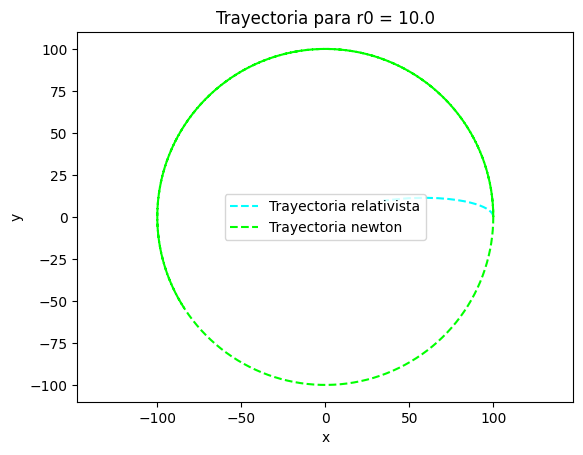

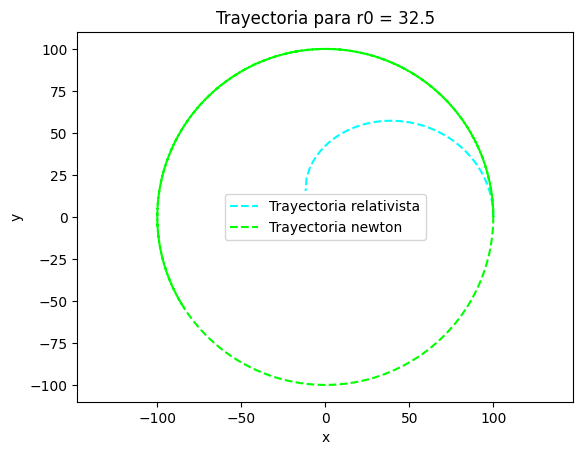

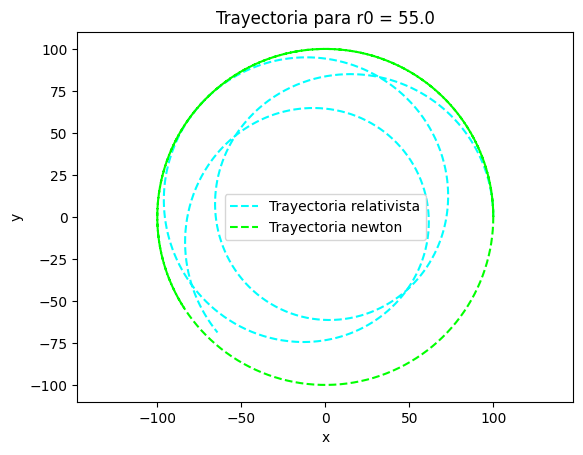

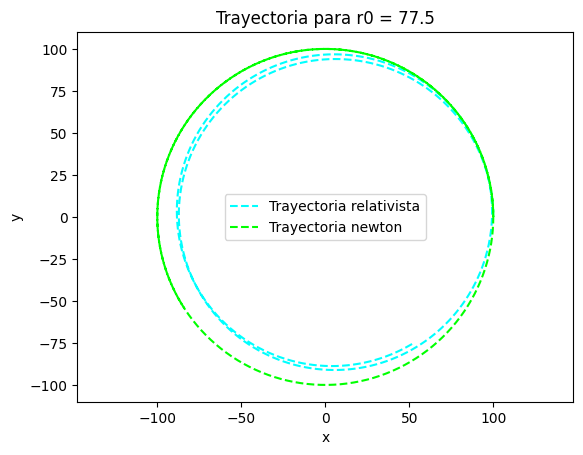

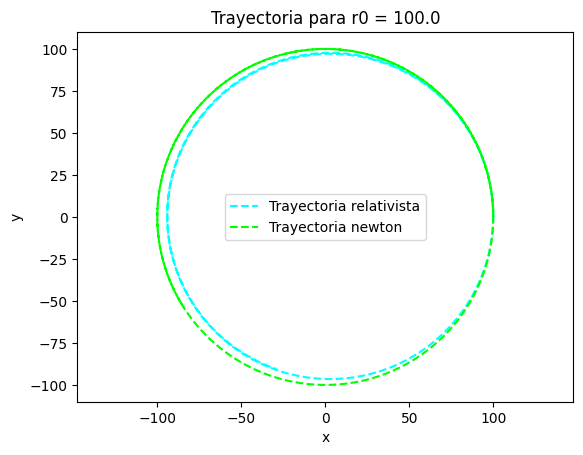

In [ ]:
r0s = np.linspace(10, 100, 5)

for i in range(len(r0s)):

  vtheta0 = np.sqrt(M/r0s[i]**3)

  y = [r0s[i], vr0, phi0, vphi0, theta0, vtheta0]
  h = r0 ** 2 * np.cos(theta0) ** 2 * vtheta0

  sol1 = solve_ivp(sistema, [ts[0], ts[-1]],
                   y0 = y0, args = (h,), t_eval=ts, method='Radau')
  sol2 = solve_ivp(sistema2, [ts[0], ts[-1]],
                   y0 = y0, args = (h,), t_eval=ts, method='Radau')

  r1 = sol1.y[0]
  r2 = sol2.y[0]

  theta1 = sol1.y[4]
  theta2 = sol2.y[4]

  x1 = r1 * np.cos(theta1)
  x2 = r2 * np.cos(theta2)

  y1 = r1 * np.sin(theta1)
  y2 = r2 * np.sin(theta2)

  plt.plot(x1, y1, '--', color='cyan', label='Trayectoria relativista')
  plt.plot(x2, y2, '--', color='lime', label='Trayectoria newton')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title(f'Trayectoria para r0 = {r0s[i]}')
  plt.legend()
  plt.axis('equal')
  plt.show()

Se observa que en los resultados del potencial newtoniano las órbitas siempre son estables y aparentemente circulares. Por el contrario, usando el potencial relativista las órbitas varían mucho dependiendo de $r_0$, especialmente cuanto éste es pequeño. Por lo tanto, se puede concluir que el potencial de Newton es una buena aproximación a la realidad únicamente cuando $r_0$ es muy grande, y para partículas que se acercan mucho al objeto central es mejor utilizar el potencial con el término relativista.

# **3. Formalismo Hamiltoniano**

Las variables auxiliares en el hamiltoniano están dadas por

$$
p_j = \frac{\partial L}{\partial \dot{q_j}}
$$

Entonces $p_r = \dot{r}$, $p_\theta = r^2 cos^2 \phi \dot{\theta}$ y $p_\phi = r^2 \dot{\phi}$

Invirtiendo se obtiene

$$
\dot{r} = p_r
$$

$$
\dot{\theta} = \frac{p_\theta}{r^2 cos^2 \phi}
$$

$$
\dot{\phi} = \frac{p_\phi}{r^2}
$$

Reemplazamos $\dot{r}$, $\dot{\theta}$ y $\dot{\phi}$ en el Lagrangiano

$$
L_{2 B}=\frac{1}{2}\left(\dot{r}^2+r^2 \cos ^2 \phi \dot{\theta}^2+r^2 \dot{\phi}^2\right)-V(r)
$$

$$
L_{qp} = \frac{1}{2} \left(p_r^2 + \frac{p_\theta^2}{r^2 cos^2\phi} + \frac{p_\phi^2}{r^2} \right) -  V(r)
$$

El Hamiltoniano está dado por

$$
H = \sum_k p_k \dot{q_k} - L_{qp}
$$

Entonces

$$
H = p_r^2 + \frac{p_\theta^2}{r^2 cos^2\phi} + \frac{p_\phi^2}{r^2} - \frac{1}{2} \left(p_r^2 + \frac{p_\theta^2}{r^2 cos^2\phi} + \frac{p_\phi^2}{r^2} \right) + V(r)
$$

$$
H = \frac{1}{2} \left(p_r^2 + \frac{p_\theta^2}{r^2 cos^2\phi} + \frac{p_\phi^2}{r^2} \right) + V(r)
$$

Las ecuaciones de Hamilton se obtienen mediante

$$
\biggl\{ \dot{q_j} = \frac{\partial H}{\partial p_j} \biggl\}
$$

$$
\biggl\{ \dot{p_j} = \frac{\partial L_{qp}}{\partial q_j} \biggl\}
$$

Entonces

$$
\dot{r} = p_r
$$

$$
\dot{\theta} = \frac{p_\theta}{r^2 cos^2 \phi}
$$

$$
\dot{\phi} = \frac{p_\phi}{r^2}
$$

Para $r$

$$
\dot{p_r} = \ddot{r} = \frac{2}{2} \frac{p_\theta^2}{r^3 cos^2 \phi} + \frac{2}{2} \frac{p_\phi^2}{r^3} - \frac{dV(r)}{dr}
$$

$$
\ddot{r} =  \frac{r^4 cos^4 \phi \dot{\theta}^2}{r^3 cos^2 \phi} +\frac{r^4 \dot{\phi}^2}{r^3} - \frac{dV(r)}{dr}
$$

$$
\ddot{r} = rcos^2 \phi \dot{\theta}^2 + r \dot{\phi}^2 - \frac{dV(r)}{dr}
$$

Para $\theta$

$$
\dot{p_\theta} = \frac{d}{dt}(r^2 cos^2 \phi \dot{\theta}) = 0
$$

$$
2 r \dot{r} cos^2\phi \dot{\theta} - 2r^2 cos\phi sin\phi \dot{\theta} \dot{\phi} + r^2 cos^2 \phi \ddot{\theta} = 0
$$

$$
\ddot{\theta} = 2 tan\phi \dot{\theta} \dot{\phi} - \frac{2 \dot{r} \dot{\theta}}{r}
$$

Además, como $\dot{p_\theta} = 0$, entonces $p_\theta$ es constante. De aquí sale la cuadratura $h = r^2 cos^2 \phi \dot{\theta}$

Para $\phi$

$$
\dot{p_\phi} = \frac{d}{dt} (r^2 \dot{\phi}) = 2r\dot{r} \dot{\phi} + r^2 \ddot{\phi} = \frac{2}{2} \frac{r^4 cos^4 \phi \dot{\theta}^2}{r^2 cos^3 \phi} sin\phi \dot{\phi}
$$

$$
\ddot{\phi} = cos \phi sin \phi \dot{\phi} \dot{\theta}^2 - \frac{2 \dot{r}\dot{\phi}}{r}
$$

Por otro lado, $t$ es cíclica, pues $\frac{\partial H}{\partial t} = 0$. En este caso, la energía E coincide con el Hamiltoniano

$$
E = H = \frac{1}{2} \left(p_r^2 + \frac{p_\theta^2}{r^2 cos^2\phi} + \frac{p_\phi^2}{r^2} \right) + V(r)
$$

Entonces, las ecuaciones de movimiento son

$$
\ddot{r} =  rcos^2 \phi \dot{\theta}^2 + r \dot{\phi}^2 - \frac{GM}{r^2} - \frac{3h^2R_S}{2r^4}
$$

$$
\ddot{\theta} = 2 tan\phi \dot{\theta} \dot{\phi} - \frac{2 \dot{r} \dot{\theta}}{r}
$$

$$
\ddot{\phi} = cos \phi sin \phi \dot{\phi} \dot{\theta}^2 - \frac{2 \dot{r}\dot{\phi}}{r}
$$

Tomando $\frac{dV(r)}{dr}=\frac{GM}{r^2} + \frac{3h^2R_S}{2r^4}$

Y las cuadraturas están dadas por

$$h = r^2 cos^2 \phi \dot{\theta}$$

$$
E = \frac{1}{2} \left( \dot{r}^2+ r^2\dot{\phi}^2+r^2cos^2\phi \dot{\theta}^2 \right) -\frac{G M}{r}-\frac{h^2 R_S}{2 r^3}
$$

Puesto que las ecuaciones de movimiento y las constantes son iguales a las obtenidas del formalismo lagrangiano, su solución numérica es igual a la presentada en el punto 2.

# **4. Precesión del Perihelio**

Para apreciar la precesión del perihelio, utilizamos la misma rutina del punto 2 pero con un $r_0$ menor

In [ ]:
r0 = 60
vr0 = 0.0
phi0 = 0.0
vphi0 = 0.0
theta0 = 0.0
vtheta0 = np.sqrt(M/r0**3)

Calculamos $h$ para las nuevas condiciones

In [ ]:
h = r0 ** 2 * np.cos(theta0) ** 2 * vtheta0

Empaquetamos las condiciones iniciales y creamos un arreglo con los tiempos

In [ ]:
y0 = [r0, vr0, phi0, vphi0, theta0, vtheta0]
ts = np.linspace(0, 10000, 1000)

Resolvemos el sistema con solve_ivp

In [ ]:
sol3 = solve_ivp(sistema, [ts[0], ts[-1]],
                 y0 = y0, args = (h,), t_eval=ts, method='Radau')

Extraemos las soluciones

In [ ]:
r3 = sol3.y[0]
vr3 = sol3.y[1]
phi3 = sol3.y[2]
vphi3 = sol3.y[3]
theta3 = sol3.y[4]
vtheta3 = sol3.y[5]

Coordenadas $x$, $y$ y $z$. En este caso $z=0$ siempre, pues se definió $\phi = 0$ y $\dot{\phi} = 0$

In [ ]:
x3 = r3 * np.cos(theta3)
y3 = r3 * np.sin(theta3)

Encontramos los perihelios para marcarlos en la gráfica

In [ ]:
"""Ayuda DeepSeek para marcar los perihelios en la gráfica

Prompt: teniendo los valores de r y theta de la trayectoria, cómo
puedo encontrar los perihelios para luego agregar dichos puntos
a la gráfica"""

from scipy.signal import argrelextrema

# Encuentra los índices de los mínimos locales (perihelios) en r3
min_indices = argrelextrema(r3, np.less)[0]

# Coordenadas de los perihelios
x_peri = r3[min_indices] * np.cos(theta3[min_indices])
y_peri = r3[min_indices] * np.sin(theta3[min_indices])
z_peri = np.zeros_like(x_peri)

Gráfica de la trayectoria

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x3, y=y3, z = z,
    mode='lines',
    line=dict(
        color='blue',
        width=4,
        colorscale='Viridis'
    ),
    name='Trayectoria Relativista',
    hovertemplate='<b>Posición</b><br>' +
                  'x: %{x:.2f}<br>' +
                  'y: %{y:.2f}<br>' +
                  'z: %{z:.2f}<br>' +
                  '<extra></extra>'
))

fig.add_trace(go.Scatter3d(
    x=x_peri,
    y=y_peri,
    z=z_peri,
    mode='markers',
    marker=dict(
        color='red',
        size=5,
        symbol='circle',
        line=dict(width=1, color='white')
    ),
    name='Perihelios',
    hovertemplate='<b>Perihelio</b><br>' +
                  'x: %{x:.2f}<br>' +
                  'y: %{y:.2f}<br>' +
                  'z: %{z:.2f}<br>' +
                  '<extra></extra>'
))

# esfera que representa el agujero negro
u = np.linspace(0, 2 * np.pi, 25)
v = np.linspace(0, np.pi, 25)
x_sphere = Rs * np.outer(np.cos(u), np.sin(v))
y_sphere = Rs * np.outer(np.sin(u), np.sin(v))
z_sphere = Rs * np.outer(np.ones(np.size(u)), np.cos(v))

fig.add_trace(go.Surface(
    x=x_sphere,
    y=y_sphere,
    z=z_sphere,
    colorscale=[[0, 'black'], [0.5, '#1a1a1a'], [1, '#333333']],
    opacity=0.95,
    showscale=False,
    name=f'Agujero negro (Rs={Rs})',
    hoverinfo='name'
))

# ejes coordenados
axis_length = (max(np.max(np.abs(x)), np.max(np.abs(y)),
                   np.max(np.abs(z))) * 1.2)

fig.add_trace(go.Scatter3d(
    x=[-axis_length, axis_length], y=[0, 0], z=[0, 0],
    mode='lines',
    line=dict(color='red', width=3, dash='dash'),
    name='Eje X',
    showlegend=False
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[-axis_length, axis_length], z=[0, 0],
    mode='lines',
    line=dict(color='green', width=3, dash='dash'),
    name='Eje Y',
    showlegend=False
))

fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[-axis_length, axis_length],
    mode='lines',
    line=dict(color='blue', width=3, dash='dash'),
    name='Eje Z',
    showlegend=False
))

fig.update_layout(
    title=dict(
        text='Trayectoria Partícula',
        x=0.5,
        font=dict(size=20)
    ),
    scene=dict(
        xaxis=dict(
            title='X',
            backgroundcolor='rgb(240, 240, 240)',
            gridcolor='white',
            zerolinecolor='white'
        ),
        yaxis=dict(
            title='Y',
            backgroundcolor='rgb(240, 240, 240)',
            gridcolor='white',
            zerolinecolor='white'
        ),
        zaxis=dict(
            title='Z',
            backgroundcolor='rgb(240, 240, 240)',
            gridcolor='white',
            zerolinecolor='white'
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        aspectmode='data'
    ),
    width=1000,
    height=800,
    showlegend=True,
    legend=dict(
        x=0,
        y=1,
        bgcolor='rgba(255, 255, 255, 0.8)'
    )
)


fig.show()

Para determinar los valores de $r$ y $\theta$ que coinciden con los perihelios, buscamos los valores mínimos en el arreglo de $r$, y guardamos los valores de $r$ y $\theta$ asociados a sus índices

In [ ]:
r_peri = []
theta_peri = []

for i in range(1, len(ts)-1):
  ra = r3[i-1]
  rb = r3[i]
  rc = r3[i+1]

  if (ra > rb) and (rb < rc):
    r_peri.append(rb)
    theta_peri.append(theta3[i])

Calculamos la diferencia de $\theta$ entre dos perihelios constitutivos. Para determinar el ángulo de la precesión, tomamos el promedio de todas las diferencias encontradas.

In [ ]:
deltastheta = []

for i in range(1, len(theta_peri)):
  deltastheta.append(theta_peri[i]% (2*np.pi) - theta_peri[i-1]% (2*np.pi))

angulo = np.mean(deltastheta)
print(f"Ángulo precesión encontrado numéricamente: {round(angulo, 4)} rad")

Ángulo precesión encontrado numéricamente: 0.364 rad


Para calcular el ángulo teórico de la precesión, necesitamos conocer $a$ y $e$ de la órbita. Pueden obtenerse de la forma

$$
a = \frac{r_{min} + r_{max}}{2}
$$

$$
e = 1 - \frac{r_{min}}{a}
$$

In [ ]:
r_min = np.min(r3)
r_max = np.max(r3)

a = (r_min + r_max) / 2
e = 1 - r_min / a

El ángulo del avance del perihelio está dado por $\Delta \theta_p = \frac{6 \pi \mu}{c^2 a(1-e^2)}$

Creamos una función para calcular el ángulo teórico

In [ ]:
def precesion(mu, a, e):
  return 6 * np.pi * mu / (c**2 * a * (1 - e**2))

Calculamos el ángulo teórico

In [ ]:
angulo_teo = precesion(M, a, e)
print(f"Ángulo precesión encontrado teóricamente: {round(angulo_teo, 4)} rad")

Ángulo precesión encontrado teóricamente: 0.3317 rad


Se observa que ambos ángulos tienen valores muy parecidos, aunque difieren a partir del segundo decimal. Dicha diferencia puede deberse a la precisión de la integración, o a que la fórmula teórica es una aproximación válida únicamente para órbitas no muy relativistas (con $r_0$ muy pequeños)

# **5. Variación en el tiempo del vector excentricidad**

En coordenadas polares, el vector excentricidad esta dado por

$$
\vec{e} = e_r \hat{u}_r + e_\theta \hat{u}_\theta
$$

Su derivada temporal es de la forma

$$
\frac{d\vec{e}}{dt} = \left( \frac{de_r}{dt} - e_\theta \dot{\theta} \right) \hat{u}_r + \left( \frac{de_\theta}{dt} + u_r \dot{\theta} \right) \hat{u}_\theta
$$

Entonces, aplicando los corchetes de Poisson

$$
\frac{d\vec{e}}{dt} = \{H, \vec{e}\}
$$

$$
\frac{d\vec{e}}{dt} = \{H, \vec{e}\} = \left( \{H, e_r\} - e_\theta \dot{\theta} \right) \hat{u}_r + \left( \{H, e_\theta\} + e_r \dot{\theta} \right) \hat{u}_\theta
$$

Donde

$$
\{H, e_r\} = \frac{\partial H}{\partial r} \frac{\partial e_r}{\partial p_r} + \frac{\partial H}{\partial \theta} \frac{\partial e_r}{\partial p_\theta} + \frac{\partial H}{\partial p_r} \frac{\partial e_r}{\partial r} + \frac{\partial H}{\partial p_\theta} \frac{\partial e_r}{\partial \theta}
$$

$$
\{H, e_\theta\} = \frac{\partial H}{\partial r} \frac{\partial e_\theta}{\partial p_r} + \frac{\partial H}{\partial \theta} \frac{\partial e_\theta}{\partial p_\theta} + \frac{\partial H}{\partial p_r} \frac{\partial e_\theta}{\partial r} + \frac{\partial H}{\partial p_\theta} \frac{\partial e_\theta}{\partial \theta}
$$